### Importação dos dados



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento



In [2]:

loja['Loja'] = 'loja_1'
loja2['Loja'] = 'loja_2'
loja3['Loja'] = 'loja_3'
loja4['Loja'] = 'loja_4'

dados = pd.concat([loja, loja2, loja3, loja4], ignore_index=True)

dados = dados.rename(columns={'Preço': 'Faturamento'})

faturamento_por_loja = dados.groupby('Loja')['Faturamento'].sum().reset_index()
faturamento_por_loja = faturamento_por_loja.sort_values(by='Faturamento', ascending=False)

display(faturamento_por_loja)

,Loja,Faturamento
0,loja_1,1534509.12
1,loja_2,1488459.06
2,loja_3,1464025.03
3,loja_4,1384497.58


In [6]:

dados.head()

,Produto,Categoria do Produto,Faturamento,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon,Loja
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79,loja_1
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66,loja_1
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86,loja_1
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50,loja_1
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38,loja_1


# 2. Vendas por Categoria

In [5]:

categorias_populares = (dados['Categoria do Produto']
                        .value_counts()
                        .reset_index())

categorias_populares.columns = ['Categoria do Produto', 'Quantidade de Vendas']

print(categorias_populares)


    Categoria do Produto  Quantidade de Vendas
0                 moveis                  1886
1            eletronicos                  1772
2             brinquedos                  1290
3       eletrodomesticos                  1149
4        esporte e lazer                  1113
5  instrumentos musicais                   753
6                 livros                   742
7  utilidades domesticas                   730


In [7]:
categorias_populares.head()

,Categoria do Produto,Quantidade de Vendas
0,moveis,1886
1,eletronicos,1772
2,brinquedos,1290
3,eletrodomesticos,1149
4,esporte e lazer,1113


# 3. Média de Avaliação das Lojas


In [9]:
media_avaliacao_lojas = (dados
    .groupby('Local da compra')['Avaliação da compra']
    .mean()
    .reset_index())

media_avaliacao_lojas.columns = ['Loja', 'Média de Avaliação']

media_avaliacao_lojas

,Loja,Média de Avaliação
0,AC,3.666667
1,AL,3.634146
2,AM,4.071429
3,AP,3.777778
4,BA,3.803226
5,CE,3.596026
6,DF,4.020661
7,ES,4.017544
8,GO,3.940860
9,MA,3.677419


In [10]:

media_avaliacao_lojas

,Loja,Média de Avaliação
0,AC,3.666667
1,AL,3.634146
2,AM,4.071429
3,AP,3.777778
4,BA,3.803226
5,CE,3.596026
6,DF,4.020661
7,ES,4.017544
8,GO,3.940860
9,MA,3.677419


# 4. Produtos Mais e Menos Vendidos

In [12]:
produtos_mais_vendidos = (dados['Produto']
    .value_counts()
    .reset_index())

produtos_mais_vendidos.columns = ['Produto', 'Quantidade de Vendas']

print(produtos_mais_vendidos)

                        Produto  Quantidade de Vendas
0                        Cômoda                   210
1      Carrinho controle remoto                   206
2                   Micro-ondas                   206
3                       Bateria                   203
4                     Cama king                   201
5            Secadora de roupas                   200
6           Modelagem preditiva                   200
7               Jogo de panelas                   200
8                      Cama box                   199
9              Blocos de montar                   199
10             Celular Plus X42                   198
11                Guarda roupas                   197
12                     Pandeiro                   197
13             Bola de basquete                   197
14                    Bicicleta                   196
15     Iniciando em programação                   195
16                     Smart TV                   192
17                    Gelade

In [14]:
produtos_menos_vendidos = (dados['Produto']
    .value_counts()
    .sort_values(ascending=True)
    .reset_index())

produtos_menos_vendidos.columns = ['Produto', 'Quantidade de Vendas']

print(produtos_menos_vendidos)

                        Produto  Quantidade de Vendas
0                  Celular ABXY                   157
1                       Headset                   158
2                       Mochila                   163
3                      Guitarra                   165
4   Ciência de dados com python                   166
5            Assistente virtual                   167
6                      Poltrona                   168
7                 Jogo de copos                   169
8             Panela de pressão                   172
9                    Smartwatch                   172
10               Fone de ouvido                   174
11                  Boneca bebê                   175
12               Mesa de centro                   175
13            Jogo de tabuleiro                   175
14               Dinossauro Rex                   175
15           Lavadora de roupas                   176
16                  Tablet ABXY                   179
17            Xadrez de made

# 5. Frete Médio por Loja

In [16]:
frete_medio_loja = (dados
    .groupby('Local da compra')['Frete']
    .mean()
    .reset_index())

frete_medio_loja.columns = ['Loja', 'Frete Médio']

frete_medio_loja

,Loja,Frete Médio
0,AC,49.361324
1,AL,33.258053
2,AM,29.368488
3,AP,21.646223
4,BA,30.257176
5,CE,25.002442
6,DF,30.185782
7,ES,33.199995
8,GO,38.129811
9,MA,35.129564


In [18]:
loja_frete_mais_barato = frete_medio_loja.sort_values(by='Frete Médio', ascending=True).iloc[0]
print(loja_frete_mais_barato)

Loja                  AP
Frete Médio    21.646223
Name: 3, dtype: object


In [20]:
loja_frete_mais_caro = frete_medio_loja.sort_values(by='Frete Médio', ascending=False).iloc[0]
print(loja_frete_mais_caro)

Loja                   RR
Frete Médio    113.673032
Name: 21, dtype: object


In [ ]:

loja_menos_lucrativa = faturamento_por_loja.nsmallest(1, 'Faturamento')

print(loja_menos_lucrativa)

     Loja  Faturamento
3  loja_4   1384497.58


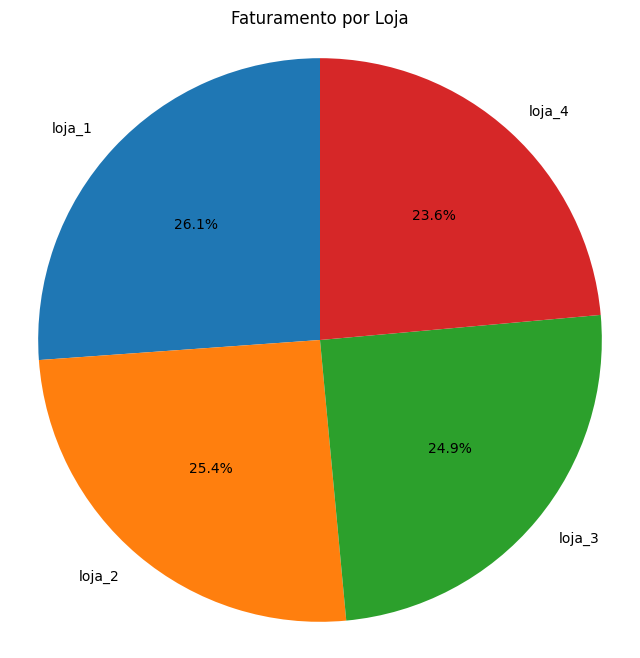

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.pie(faturamento_por_loja['Faturamento'], labels=faturamento_por_loja['Loja'], autopct='%1.1f%%', startangle=90)
plt.title('Faturamento por Loja')
plt.axis('equal')
plt.show()

/tmp/ipykernel_186/1324704827.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Loja', y='Média de Avaliação', data=media_avaliacao_lojas_sorted, palette='viridis')


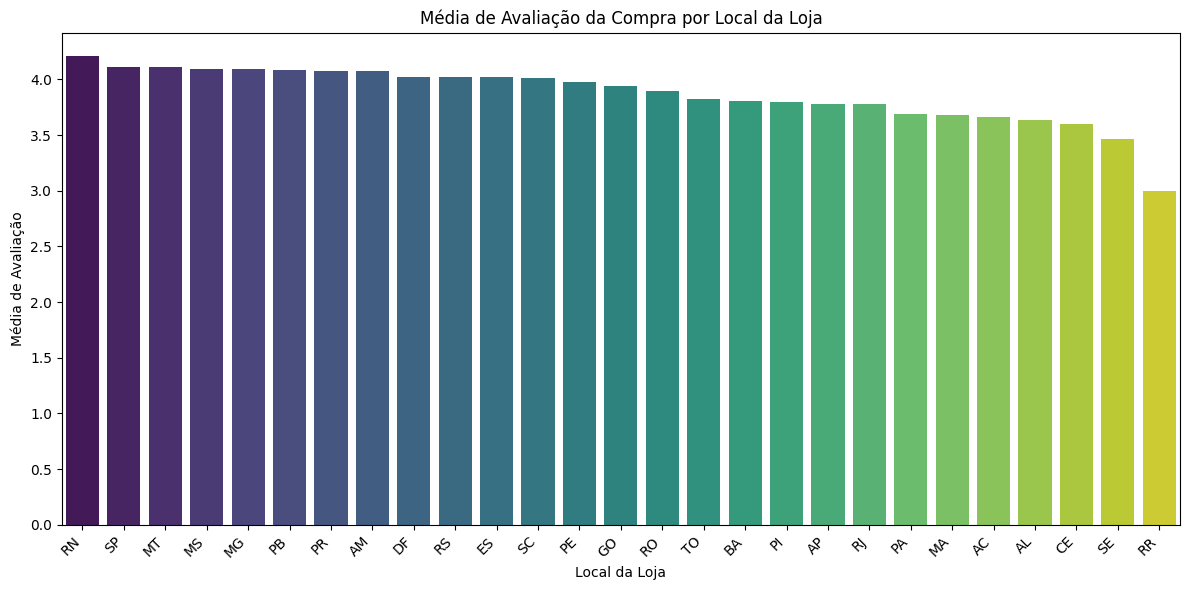

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

media_avaliacao_lojas_sorted = media_avaliacao_lojas.sort_values(by='Média de Avaliação', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Loja', y='Média de Avaliação', data=media_avaliacao_lojas_sorted, palette='viridis')
plt.title('Média de Avaliação da Compra por Local da Loja')
plt.xlabel('Local da Loja')
plt.ylabel('Média de Avaliação')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


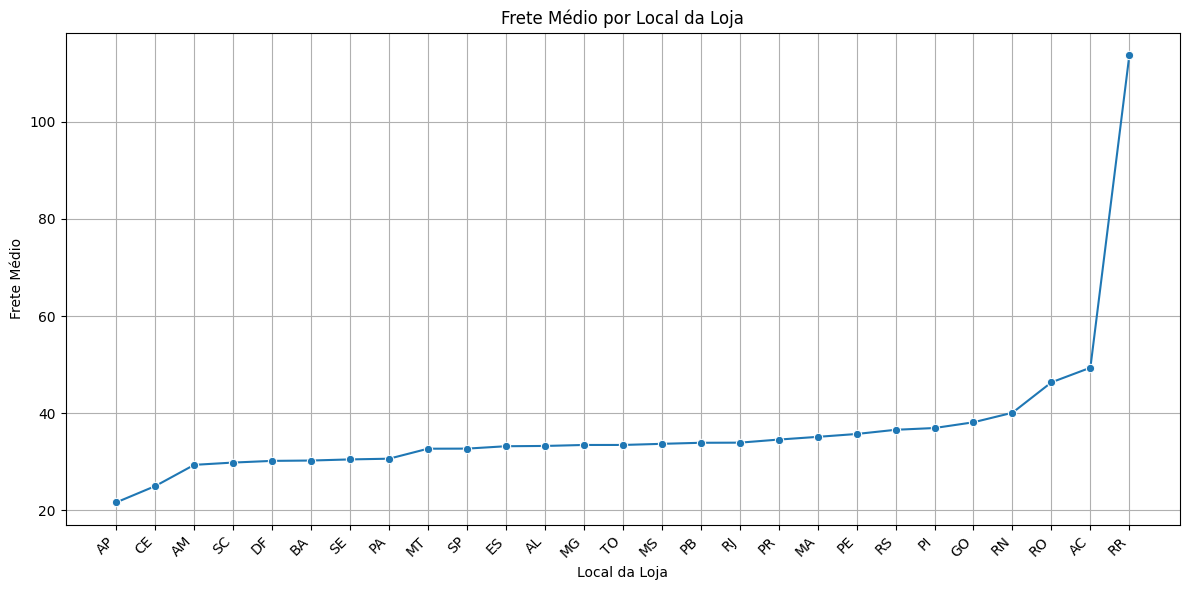

A loja com o frete mais barato é: AP com um frete médio de 21.65


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

frete_medio_loja_sorted = frete_medio_loja.sort_values(by='Frete Médio', ascending=True)

plt.figure(figsize=(12, 6))
sns.lineplot(x='Loja', y='Frete Médio', data=frete_medio_loja_sorted, marker='o')
plt.title('Frete Médio por Local da Loja')
plt.xlabel('Local da Loja')
plt.ylabel('Frete Médio')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"A loja com o frete mais barato é: {frete_medio_loja_sorted.iloc[0]['Loja']} com um frete médio de {frete_medio_loja_sorted.iloc[0]['Frete Médio']:.2f}")

Dentre as lojas analisadas é possivel pressumir que a loja 4 é a menos rentável de todas, porém,  a diferenca entre o faturamento das outras lojas é infima, representando apenas 2,5 % do percentual total. Sendo assim a recomdação ao Sr. João, sendo está a possível de venda dentre as demais analisadas.